# CNV benchmark

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import seaborn.objects as so

custom_params = {
    "axes.spines.right": False, 
    "axes.spines.top": False,
    "axes.edgecolor": "k",
}

sns.set_theme(
    context="notebook",
    style="ticks", 
    palette="colorblind",
    font_scale=1.1,
    rc=custom_params
)

# For SVG output
plt.rcParams['svg.fonttype'] = 'none'
figdir = Path("../figures/svg")

In [35]:
base_path = Path("../analysis/cnv_benchmark")

samples = pd.read_csv("../sample_info.tsv", sep="\t") 
samples["Type"] = samples["IsSingleCell"].replace({True: "Single cell", False: "Bulk"})
samples["Cell"] = "#" + samples["User ID"].str.split("_").str[-1]
# Remove for bulk samples
samples["Cell"] = samples["Cell"].str.replace("#cells", "")
human_samples = samples.query("Genome == 'Human'")
human_samples

,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type,Cell
0,P33410_1001,Q_B2_cell_01,True,MDA/REPLI-g,MM1S cell line,Human,MDA/REPLI-g (Cell#01),Single cell,#01
1,P33410_1002,Q_C2_cell_02,True,MDA/REPLI-g,MM1S cell line,Human,MDA/REPLI-g (Cell#02),Single cell,#02
2,P33410_1003,Q_D2_cell_03,True,MDA/REPLI-g,MM1S cell line,Human,MDA/REPLI-g (Cell#03),Single cell,#03
3,P33410_1004,Q_E2_cell_04,True,MDA/REPLI-g,MM1S cell line,Human,MDA/REPLI-g (Cell#04),Single cell,#04
4,P33410_1005,Q_F2_cell_05,True,MDA/REPLI-g,MM1S cell line,Human,MDA/REPLI-g (Cell#05),Single cell,#05
5,P33410_1006,Q_G2_cell_06,True,MDA/REPLI-g,MM1S cell line,Human,MDA/REPLI-g (Cell#06),Single cell,#06
7,P33410_1008,Q_A3_cell_07,True,MDA/REPLI-g,MM1S cell line,Human,MDA/REPLI-g (Cell#07),Single cell,#07
8,P33410_1009,Q_B3_cell_08,True,MDA/REPLI-g,MM1S cell line,Human,MDA/REPLI-g (Cell#08),Single cell,#08
9,P33410_1010,Q_C3_cell_09,True,MDA/REPLI-g,MM1S cell line,Human,MDA/REPLI-g (Cell#09),Single cell,#09
10,P33410_1011,Q_D3_cell_10,True,MDA/REPLI-g,MM1S cell line,Human,MDA/REPLI-g (Cell#10),Single cell,#10


In [36]:
data = []

for tsv in (base_path / "agreement").rglob("*.stats.tsv"):
    print(tsv)
    binsize, *_ = tsv.stem.split(".")
    truthset = tsv.parent.stem
    readdepth = tsv.parent.parent.stem
    caller = tsv.parent.parent.parent.stem

    # Skip OGM
    if truthset == "OGM":
        continue

    df = pd.read_csv(
        tsv, 
        sep="\t", 
        header=0,
    )
    df["Truthset"] = truthset
    df["Caller"] = caller
    df["Binsize"] = binsize
    df["Readdepth"] = readdepth
    df["NGI ID"] = df["Name"]

    if "penncnv" == caller:
        # Replace names
        df["NGI ID"] = df["NGI ID"].replace(samples.set_index("User ID")["NGI ID"].to_dict())
    data.append(df)

data = pd.concat(data).reset_index(drop=True)
data = data.merge(samples, on="NGI ID")
data = data.query("Genome == 'Human'")
data["Caller_Binsize"] = data[["Caller","Binsize"]].apply(lambda x: f"{x[0]}\n\n({x[1]})", axis=1)
data["Kit_Readdepth"] = data[["Kit","Readdepth"]].apply(lambda x: f"{x[0]} ({x[1]})", axis=1)

assert (data[["TPs", "FPs", "FNs"]].sum(axis=1) == data["TotalBases"]).all()

data

../analysis/cnv_benchmark/agreement/penncnv/array/PacBio_HiFi/none.stats.tsv
../analysis/cnv_benchmark/agreement/copykit/full/PacBio_HiFi/220kb.stats.tsv
../analysis/cnv_benchmark/agreement/copykit/full/PacBio_HiFi/1Mb.stats.tsv
../analysis/cnv_benchmark/agreement/copykit/full/PacBio_HiFi/500kb.stats.tsv
../analysis/cnv_benchmark/agreement/copykit/full/PacBio_HiFi/110kb.stats.tsv
../analysis/cnv_benchmark/agreement/copykit/40M/PacBio_HiFi/220kb.stats.tsv
../analysis/cnv_benchmark/agreement/copykit/40M/PacBio_HiFi/1Mb.stats.tsv
../analysis/cnv_benchmark/agreement/copykit/40M/PacBio_HiFi/500kb.stats.tsv
../analysis/cnv_benchmark/agreement/copykit/40M/PacBio_HiFi/110kb.stats.tsv
../analysis/cnv_benchmark/agreement/copykit/2M/PacBio_HiFi/220kb.stats.tsv
../analysis/cnv_benchmark/agreement/copykit/2M/PacBio_HiFi/1Mb.stats.tsv
../analysis/cnv_benchmark/agreement/copykit/2M/PacBio_HiFi/500kb.stats.tsv
../analysis/cnv_benchmark/agreement/copykit/2M/PacBio_HiFi/110kb.stats.tsv
../analysis/cnv_b

/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_98077/2439789914.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data["Caller_Binsize"] = data[["Caller","Binsize"]].apply(lambda x: f"{x[0]}\n\n({x[1]})", axis=1)
/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_98077/2439789914.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data["Kit_Readdepth"] = data[["Kit","Readdepth"]].apply(lambda x: f"{x[0]} ({x[1]})", axis=1)


,Name,TotalBases,TPs,FPs,FNs,Agreement,Precision,Recall,F1Score,Truthset,...,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type,Cell,Caller_Binsize,Kit_Readdepth
0,B_A3_cell_01,2852430000,2608198453,34604882,209626665,0.914378,0.986906,0.925607,0.955274,PacBio_HiFi,...,B_A3_cell_01,True,PTA/ResolveDNA,MM1S cell line,Human,PTA/ResolveDNA (Cell#01),Single cell,#01,penncnv\n\n(none),PTA/ResolveDNA (array)
1,B_A4_cell_02,2852430000,2562019639,49434583,240975778,0.898188,0.981070,0.914029,0.946364,PacBio_HiFi,...,B_A4_cell_02,True,PTA/ResolveDNA,MM1S cell line,Human,PTA/ResolveDNA (Cell#02),Single cell,#02,penncnv\n\n(none),PTA/ResolveDNA (array)
2,B_B1_cell_03,2852430000,2602822952,28601549,221005499,0.912493,0.989131,0.921736,0.954245,PacBio_HiFi,...,B_B1_cell_03,True,PTA/ResolveDNA,MM1S cell line,Human,PTA/ResolveDNA (Cell#03),Single cell,#03,penncnv\n\n(none),PTA/ResolveDNA (array)
3,B_B2_cell_04,2852430000,2290355427,278276105,283798468,0.802949,0.891664,0.889751,0.890706,PacBio_HiFi,...,B_B2_cell_04,True,PTA/ResolveDNA,MM1S cell line,Human,PTA/ResolveDNA (Cell#04),Single cell,#04,penncnv\n\n(none),PTA/ResolveDNA (array)
4,B_B3_cell_05,2852430000,2588668852,38784065,224977083,0.907531,0.985239,0.920041,0.951524,PacBio_HiFi,...,B_B3_cell_05,True,PTA/ResolveDNA,MM1S cell line,Human,PTA/ResolveDNA (Cell#05),Single cell,#05,penncnv\n\n(none),PTA/ResolveDNA (array)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284,P33410_1019,2852430000,778465291,1536115078,537849631,0.272913,0.336331,0.591397,0.428801,PacBio_HiFi,...,B_C1_cell_07,True,PTA/ResolveDNA,MM1S cell line,Human,PTA/ResolveDNA (Cell#07),Single cell,#07,ginkgo\n\n(1Mb),PTA/ResolveDNA (2M)
285,P33410_1020,2852430000,1289069734,1139154630,424205636,0.451920,0.530869,0.752401,0.622513,PacBio_HiFi,...,B_C2_cell_08,True,PTA/ResolveDNA,MM1S cell line,Human,PTA/ResolveDNA (Cell#08),Single cell,#08,ginkgo\n\n(1Mb),PTA/ResolveDNA (2M)
286,P33410_1021,2852430000,2670145624,151570996,30713380,0.936095,0.946284,0.988628,0.966993,PacBio_HiFi,...,B_C3_cell_09,True,PTA/ResolveDNA,MM1S cell line,Human,PTA/ResolveDNA (Cell#09),Single cell,#09,ginkgo\n\n(1Mb),PTA/ResolveDNA (2M)
287,P33410_1022,2852430000,2680892413,131167322,40370265,0.939863,0.953355,0.985165,0.968999,PacBio_HiFi,...,B_C4_cell_10,True,PTA/ResolveDNA,MM1S cell line,Human,PTA/ResolveDNA (Cell#10),Single cell,#10,ginkgo\n\n(1Mb),PTA/ResolveDNA (2M)


### SNP array vs 2M reads

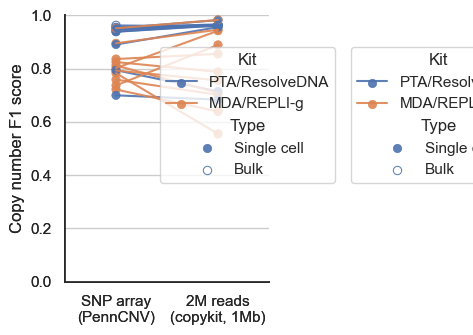

In [37]:
readdepth = ["2M", "array"]
caller = ["penncnv", "copykit"]
binsize = ["none", "1Mb"]
d = data.query(
    "Readdepth in @readdepth & Caller in @caller\
    & Binsize in @binsize & Truthset == 'PacBio_HiFi'").copy()
d["Caller_Binsize"] = d["Caller"] + "\n(" + d["Binsize"] + ")"

rename = {
    "array": "SNP array\n(PennCNV)",
    "2M": "2M reads\n(copykit, 1Mb)"
}

d["data"] = d["Readdepth"].replace(rename)
d = d.sort_values("Type", ascending=False)
fig = plt.figure(figsize=(3.5,4))
p = (
    so.Plot(d, x="data", y="F1Score", color="Kit", group="SampleName", text="Cell")
    .add(so.Dot(alpha=0.9), fill="Type")
    .add(so.Path(alpha=0.9))
    .add(so.Text(halign="left", fontsize=8), so.Shift(), data=d.query("data == '2M reads'"))
    
    .label(y="Copy number F1 score", x="")
    .limit(y=(0, 1))
    .scale(
        color=so.Nominal(order=["PTA/ResolveDNA", "MDA/REPLI-g"]),
        x=so.Nominal(order=list(rename.values())),
    )
    .layout(engine="tight")
    .theme(sns.axes_style("whitegrid") | sns.plotting_context("notebook"))
    .theme(custom_params)
    .on(fig)
    .save(figdir / "cnv_f1_score_array_vs_2M_pacbio.svg", dpi=300, bbox_inches="tight", transparent=True)
)

p.show()

In [38]:
d.groupby(["Type", "Readdepth", "Kit"])["F1Score"].median().reset_index()

,Type,Readdepth,Kit,F1Score
0,Bulk,2M,MDA/REPLI-g,0.982833
1,Bulk,2M,PTA/ResolveDNA,0.958619
2,Bulk,array,MDA/REPLI-g,0.951558
3,Bulk,array,PTA/ResolveDNA,0.962248
4,Single cell,2M,MDA/REPLI-g,0.771963
5,Single cell,2M,PTA/ResolveDNA,0.964096
6,Single cell,array,MDA/REPLI-g,0.797508
7,Single cell,array,PTA/ResolveDNA,0.942744


In [39]:
print(d.pivot(index=["SampleName"], columns=["Readdepth"], values=["F1Score"]).round(2).to_csv())

,F1Score,F1Score
Readdepth,2M,array
SampleName,,
MDA/REPLI-g (Bulk),0.98,0.95
MDA/REPLI-g (Cell#01),0.86,0.84
MDA/REPLI-g (Cell#02),0.89,0.74
MDA/REPLI-g (Cell#03),0.64,0.72
MDA/REPLI-g (Cell#04),0.94,0.8
MDA/REPLI-g (Cell#05),0.71,0.81
MDA/REPLI-g (Cell#06),0.7,0.76
MDA/REPLI-g (Cell#07),0.79,0.82
MDA/REPLI-g (Cell#08),0.95,0.9
MDA/REPLI-g (Cell#09),0.76,0.79
MDA/REPLI-g (Cell#10),0.56,0.78
PTA/ResolveDNA (Bulk),0.96,0.96
PTA/ResolveDNA (Cell#01),0.96,0.96
PTA/ResolveDNA (Cell#02),0.96,0.95
PTA/ResolveDNA (Cell#03),0.97,0.95
PTA/ResolveDNA (Cell#04),0.96,0.89
PTA/ResolveDNA (Cell#05),0.98,0.95
PTA/ResolveDNA (Cell#06),0.96,0.94
PTA/ResolveDNA (Cell#07),0.68,0.7
PTA/ResolveDNA (Cell#08),0.71,0.79
PTA/ResolveDNA (Cell#09),0.96,0.95
PTA/ResolveDNA (Cell#10),0.96,0.94



## CNVs across read depth, caller and binsize

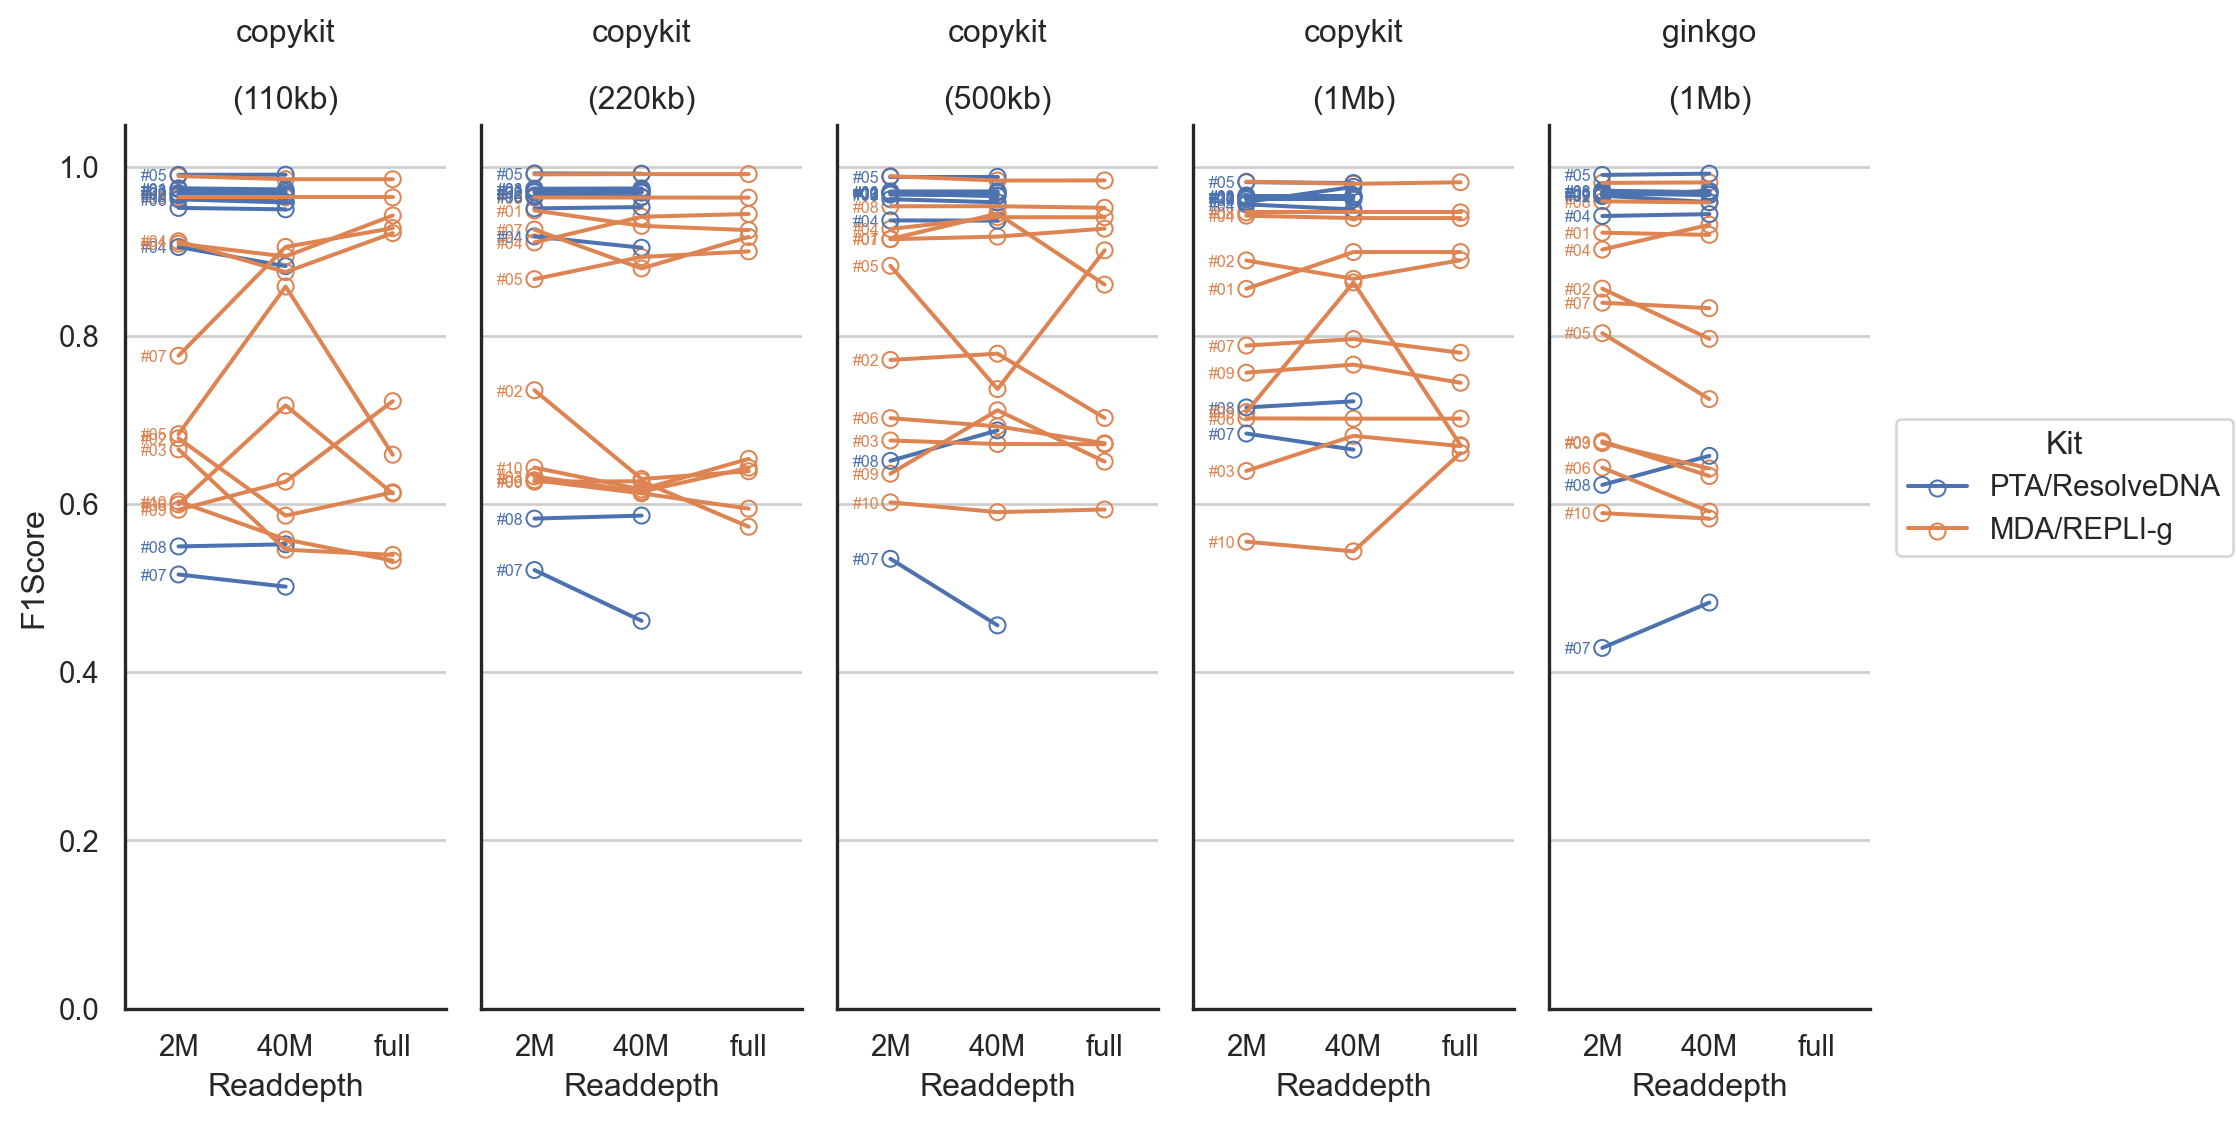

In [49]:
d = data.query("Binsize != 'none' & Truthset == 'PacBio_HiFi'")
d = d.sort_values(["Kit_Readdepth"])

hue_order = sorted(d["Kit_Readdepth"].unique())
d["Range"] = d["Kit_Readdepth"].map(dict(zip(hue_order, range(len(hue_order)))))
col_order = [
    'copykit\n\n(110kb)',
    'copykit\n\n(220kb)',
    'copykit\n\n(500kb)',
    'copykit\n\n(1Mb)',
    'ginkgo\n\n(1Mb)'
]
d = d.query("Caller_Binsize in @col_order")
d["Caller_Binsize"] = pd.Categorical(d["Caller_Binsize"], categories=col_order, ordered=True)

p = (
    so.Plot(data=d, x="Readdepth", y="F1Score", color="Kit", group="SampleName", text="Cell")
    .facet(col="Caller_Binsize")
    .add(so.Dot(fill=None))
    .add(so.Path())
    .add(so.Text(halign="right", fontsize=6), data=d.query("Readdepth == '2M'"))
    .limit(x=(-0.5, 2.5), y=(0, 1.05))
    .scale(
        color=so.Nominal(order=["PTA/ResolveDNA", "MDA/REPLI-g"]),
        x=so.Nominal(order=["2M", "40M", "full"])
    )
    .layout(engine="tight", size=(10, 6))

    .theme(sns.axes_style("whitegrid") | sns.plotting_context("notebook"))
    .theme(custom_params)
    .save(figdir / "cnv_benchmark_f1_vs_pacbio.svg", dpi=300, bbox_inches="tight", transparent=True)
)
p

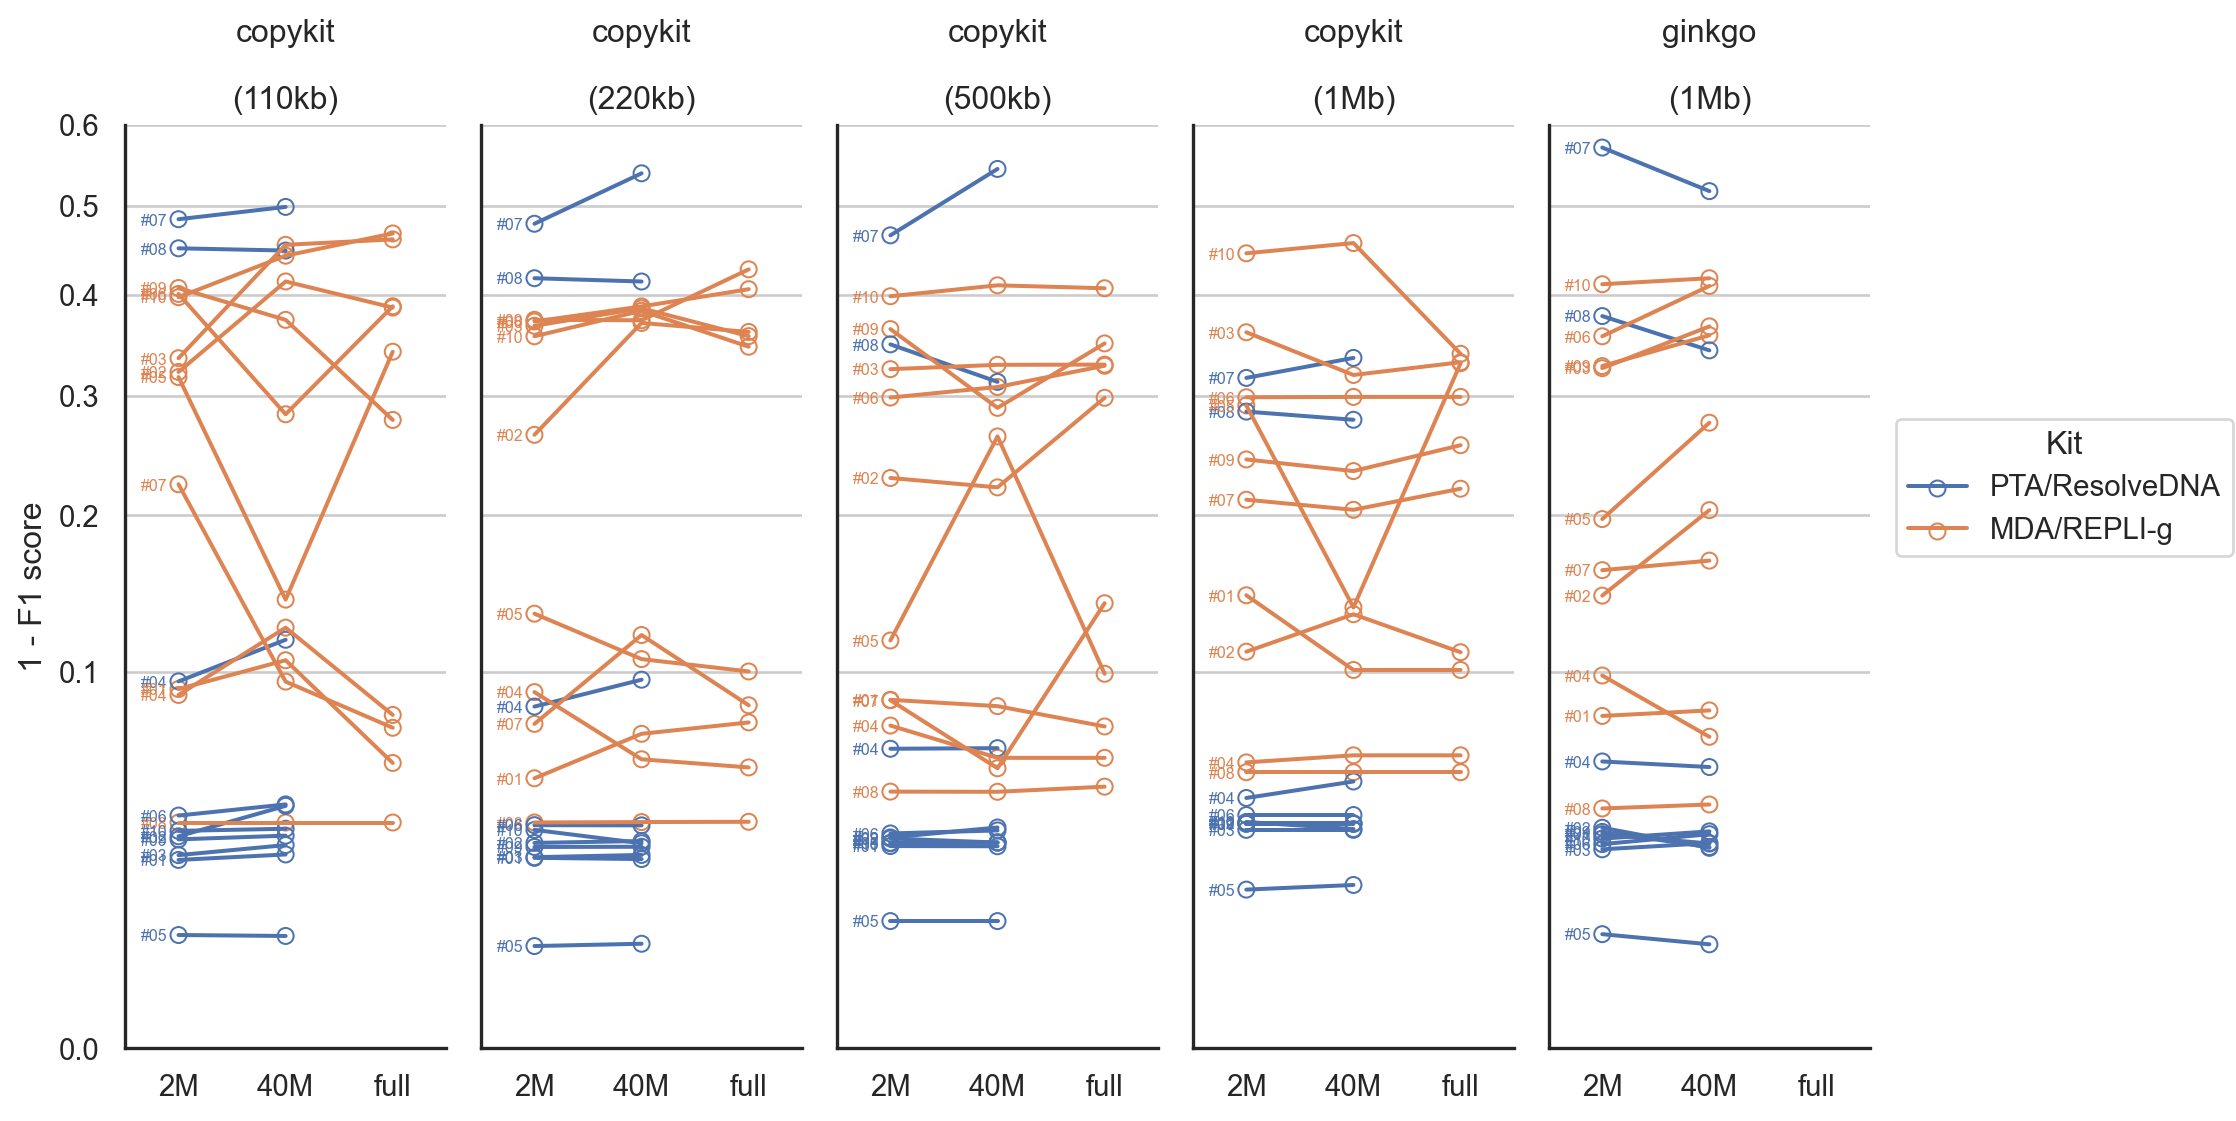

In [ ]:
d = data.query("IsSingleCell == True & Binsize != 'none' & Truthset == 'PacBio_HiFi'")
#d = data.query("Binsize != 'none' & Truthset == 'PacBio_HiFi'")
d = d.sort_values(["Kit_Readdepth"])

hue_order = sorted(d["Kit_Readdepth"].unique())
d["Range"] = d["Kit_Readdepth"].map(dict(zip(hue_order, range(len(hue_order)))))
d = d.query("Caller_Binsize in @col_order")
d["Caller_Binsize"] = pd.Categorical(d["Caller_Binsize"], categories=col_order, ordered=True)
d["1-F1"] = 1 - d["F1Score"]
p = (
    so.Plot(data=d, x="Readdepth", y="1-F1", color="Kit", group="SampleName", text="Cell")
    .facet(col="Caller_Binsize")
    .add(so.Dot(fill=None))
    .add(so.Path())
    .add(so.Text(halign="right", fontsize=6), data=d.query("Readdepth == '2M'"))
    .limit(x=(-0.5, 2.5), y=(0, 0.6))
    .scale(
        color=so.Nominal(order=["PTA/ResolveDNA", "MDA/REPLI-g"]),
        x=so.Nominal(order=["2M", "40M", "full"]),
        y=so.Continuous(trans="sqrt").label(base=None)
    )
    .layout(engine="tight", size=(10, 6))
    .label(y="1 - F1 score", x="")
    .theme(sns.axes_style("whitegrid") | sns.plotting_context("notebook"))
    .theme(custom_params)
    #.save(figdir / "cnv_benchmark_f1_vs_pacbio.svg", dpi=300, bbox_inches="tight", transparent=True)
)
p

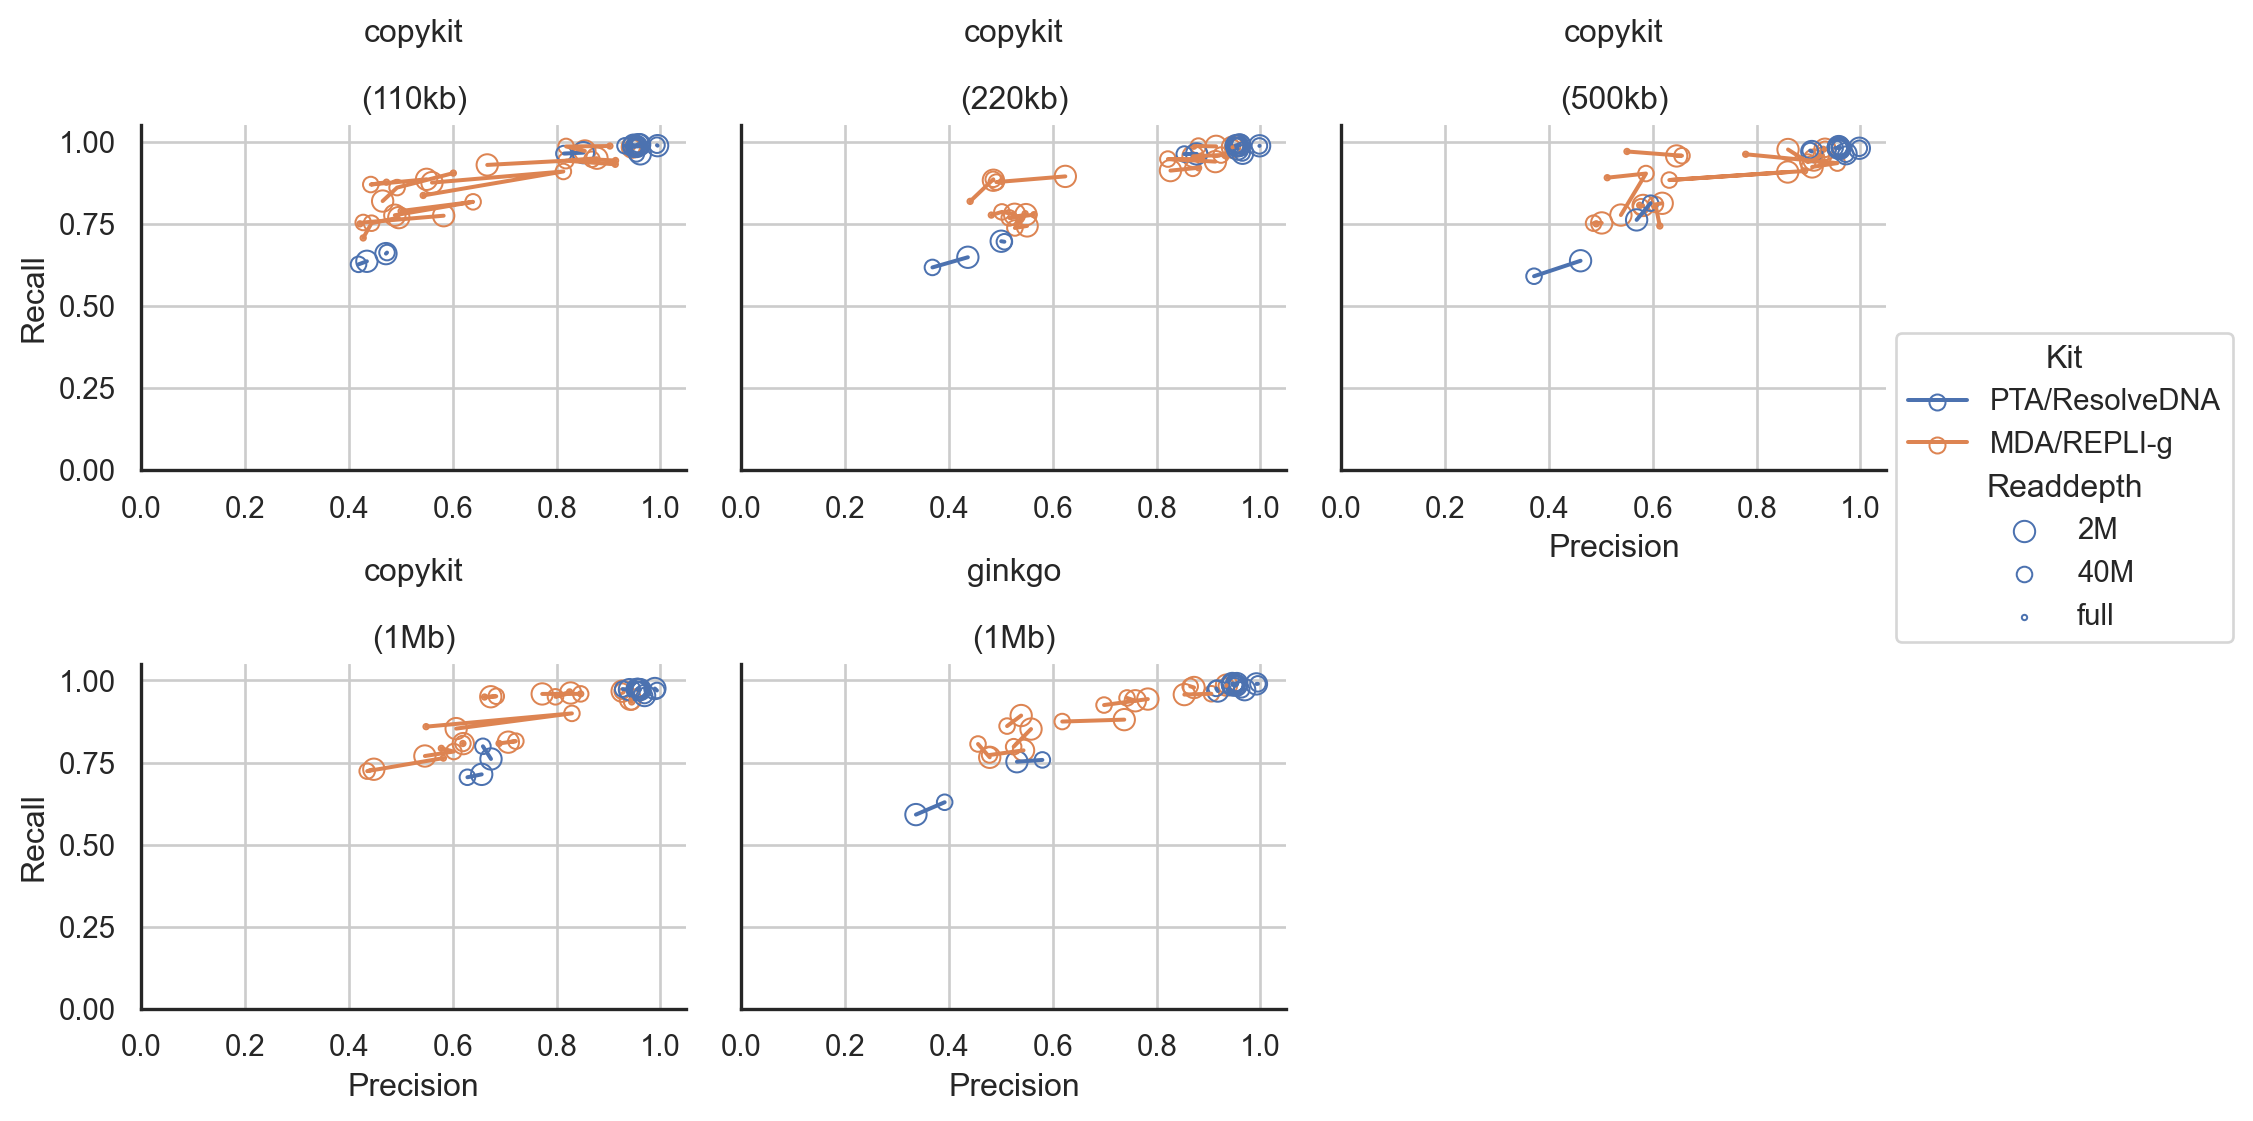

In [48]:
d = data.query("IsSingleCell == True & Binsize != 'none' & Truthset == 'PacBio_HiFi'")
d = d.sort_values(["Kit_Readdepth"])

hue_order = sorted(d["Kit_Readdepth"].unique())
d["Range"] = d["Kit_Readdepth"].map(dict(zip(hue_order, range(len(hue_order)))))
d = d.query("Caller_Binsize in @col_order")
d["Caller_Binsize"] = pd.Categorical(d["Caller_Binsize"], categories=col_order, ordered=True)

p = (
    so.Plot(data=d, x="Precision", y="Recall", color="Kit", group="SampleName", text="Cell")
    .facet(col="Caller_Binsize", wrap=3)
    .add(so.Dot(fill=None), pointsize="Readdepth")
    .add(so.Path(), group="SampleName")
    #.add(so.Text(halign="right", fontsize=6), data=d.query("Readdepth == '2M'"))
    .limit(x=(0, 1.05), y=(0, 1.05))
    .scale(
        color=so.Nominal(order=["PTA/ResolveDNA", "MDA/REPLI-g"]),
    )
    .layout(engine="tight", size=(10, 6))
    .share(x=False)
    .theme(sns.axes_style("whitegrid") | sns.plotting_context("notebook"))
    .theme(custom_params)
#    .save(figdir / "cnv_benchmark_f1_vs_pacbio.svg", dpi=300, bbox_inches="tight", transparent=True)
)
p

In [10]:
data.query("Binsize != 'none'")\
    .groupby(["Kit", "Type"]).agg(
    median_F1=("F1Score", "median"),
    std_F1=("F1Score", "std"),
).reset_index()

,Kit,Type,median_F1,std_F1
0,MDA/REPLI-g,Bulk,0.984974,0.004153
1,MDA/REPLI-g,Single cell,0.773473,0.139764
2,PTA/ResolveDNA,Bulk,0.958377,0.008223
3,PTA/ResolveDNA,Single cell,0.966368,0.161516
